# Ejercicio 6 
A continuacion elaboraremos casos de Benchmarking para el calculo de pesos segun cada algoritmo de los tres brindados.

In [1]:
# Imports necesarios
import numpy as np
import matplotlib.pyplot as plt
from alc import *
path_base = "./cats_and_dogs"
X_t, Y_t, X_v, Y_v = cargarDataset(path_base) # Siendo _t nuestros modelos de training (entrenamiento) y _v de validation (validacion)

Calculamos los W para cada método y generamos las matrices de confusión utilizandolos:

In [ ]:
# Dado cada modelo pedimos una matriz W
W_Cholesky = fullyConnectedLineal_Cholesky(X_t, Y_t)
print("FINALIZO CHOLESKY")
W_QR = fullyConnectedLineal_QR(X_t, Y_t)
print("FINALIZO QR")
W_SVD = fullyConnectedLineal_SVD(X_t, Y_t)
print("FINALIZO SDV")

Y_Cholesky = productoMatricial(W_Cholesky, X_v)
Y_QR = productoMatricial(W_QR, X_v)
Y_SVD = productoMatricial(W_SVD, X_v)

matrizConfusion_Cholesky = np.zeros((2,2))
matrizConfusion_QR = np.zeros((2,2))
matrizConfusion_SVD = np.zeros((2,2))

def actualizarMatrizDeConfusion(matrizConfusion, esPerro, esPerro_Predicho):
    if esPerro and esPerro_Predicho:
        matrizConfusion[1][1] += 1
    elif esPerro and not esPerro_Predicho:
        matrizConfusion[1][0] += 1
    elif not esPerro and esPerro_Predicho:     
        matrizConfusion[0][1] += 1
    else:     
        matrizConfusion[0][0] += 1

row_Y, col_Y  = Y_Cholesky.shape # Tienen todas el mismo tamaño
for i in range(col_Y):
    esPerro = Y_v[0][i] == 1

    esPerro_Cholesky = Y_Cholesky[0][i] >= Y_Cholesky[1][i]
    esPerro_QR = Y_QR[0][i] >= Y_QR[1][i]
    esPerro_SVD = Y_SVD[0][i] >= Y_SVD[1][i]

    actualizarMatrizDeConfusion(matrizConfusion_Cholesky, esPerro, esPerro_Cholesky)
    actualizarMatrizDeConfusion(matrizConfusion_QR, esPerro, esPerro_QR)
    actualizarMatrizDeConfusion(matrizConfusion_SVD, esPerro, esPerro_SVD)


X_cols [array([-0.00417685, -0.01141437,  0.07058331,  0.00168005,  0.00166057,
        0.00935192,  0.03020145, -0.0215533 , -0.00228349, -0.00343372,
        0.04694948, -0.00117653,  0.02275904, -0.0230354 ,  0.02864548,
       -0.00712682, -0.00793945, -0.0058538 ,  0.0042009 ,  0.01922112]), array([ 0.01352901,  0.02366493, -0.01134131,  0.00662406,  0.04679327,
       -0.0049329 , -0.01951112,  0.0043484 ,  0.01179972, -0.00906119,
        0.00403433, -0.02354503,  0.0116593 ,  0.00864142,  0.03194285,
        0.00927548,  0.02251175, -0.00725882, -0.01077429,  0.00027191]), array([ 0.01111219, -0.00242191,  0.0184618 ,  0.00230902, -0.0108787 ,
        0.00773504,  0.00460859,  0.02208158,  0.00675471, -0.02231139,
        0.02854714, -0.03163353, -0.01474605,  0.00627258, -0.02386472,
        0.00395892,  0.00123876,  0.02166075,  0.02534267, -0.01836824]), array([ 0.01390484,  0.03947868,  0.02645306, -0.01432021, -0.02091863,
        0.03035264, -0.01738093, -0.00791304, -0.0

ValueError: not enough values to unpack (expected 2, got 1)

Ahora queremos ver los resultados para cada una. Para esto vamos a graficar con matplotlib

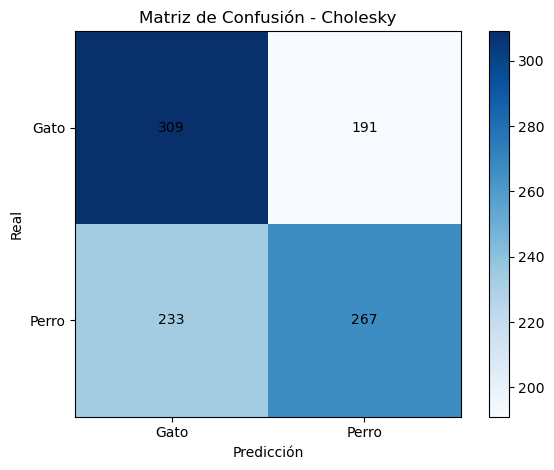

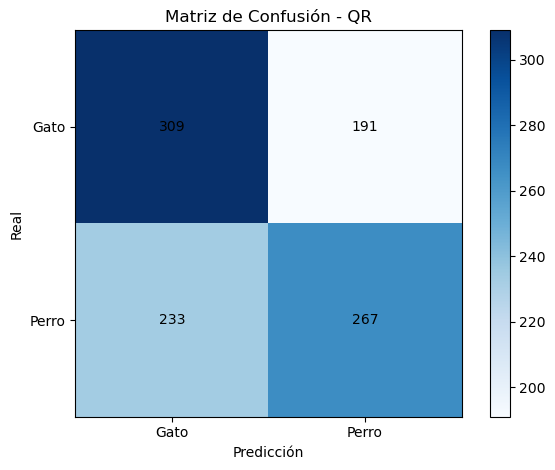

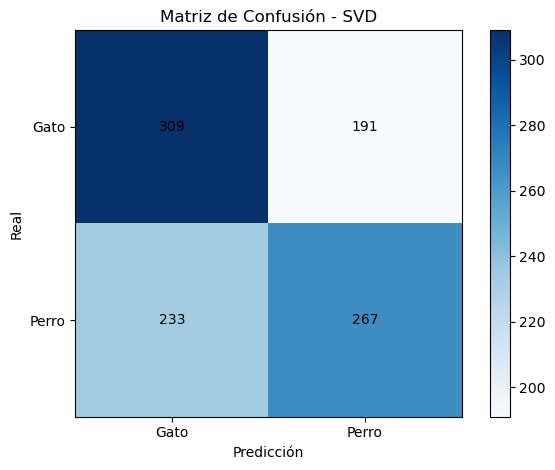

In [ ]:
def plot_confusion_matrix(cm, title):
    fig, ax = plt.subplots()
    im = ax.imshow(cm, cmap="Blues")

    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(["Gato", "Perro"])
    ax.set_yticklabels(["Gato", "Perro"])
    ax.set_xlabel("Predicción")
    ax.set_ylabel("Real")
    ax.set_title(title)

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, int(cm[i, j]),
                    ha="center", va="center")

    fig.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.show()
    
plot_confusion_matrix(matrizConfusion_Cholesky, "Matriz de Confusión - Cholesky")
plot_confusion_matrix(matrizConfusion_QR, "Matriz de Confusión - QR")
plot_confusion_matrix(matrizConfusion_SVD, "Matriz de Confusión - SVD")